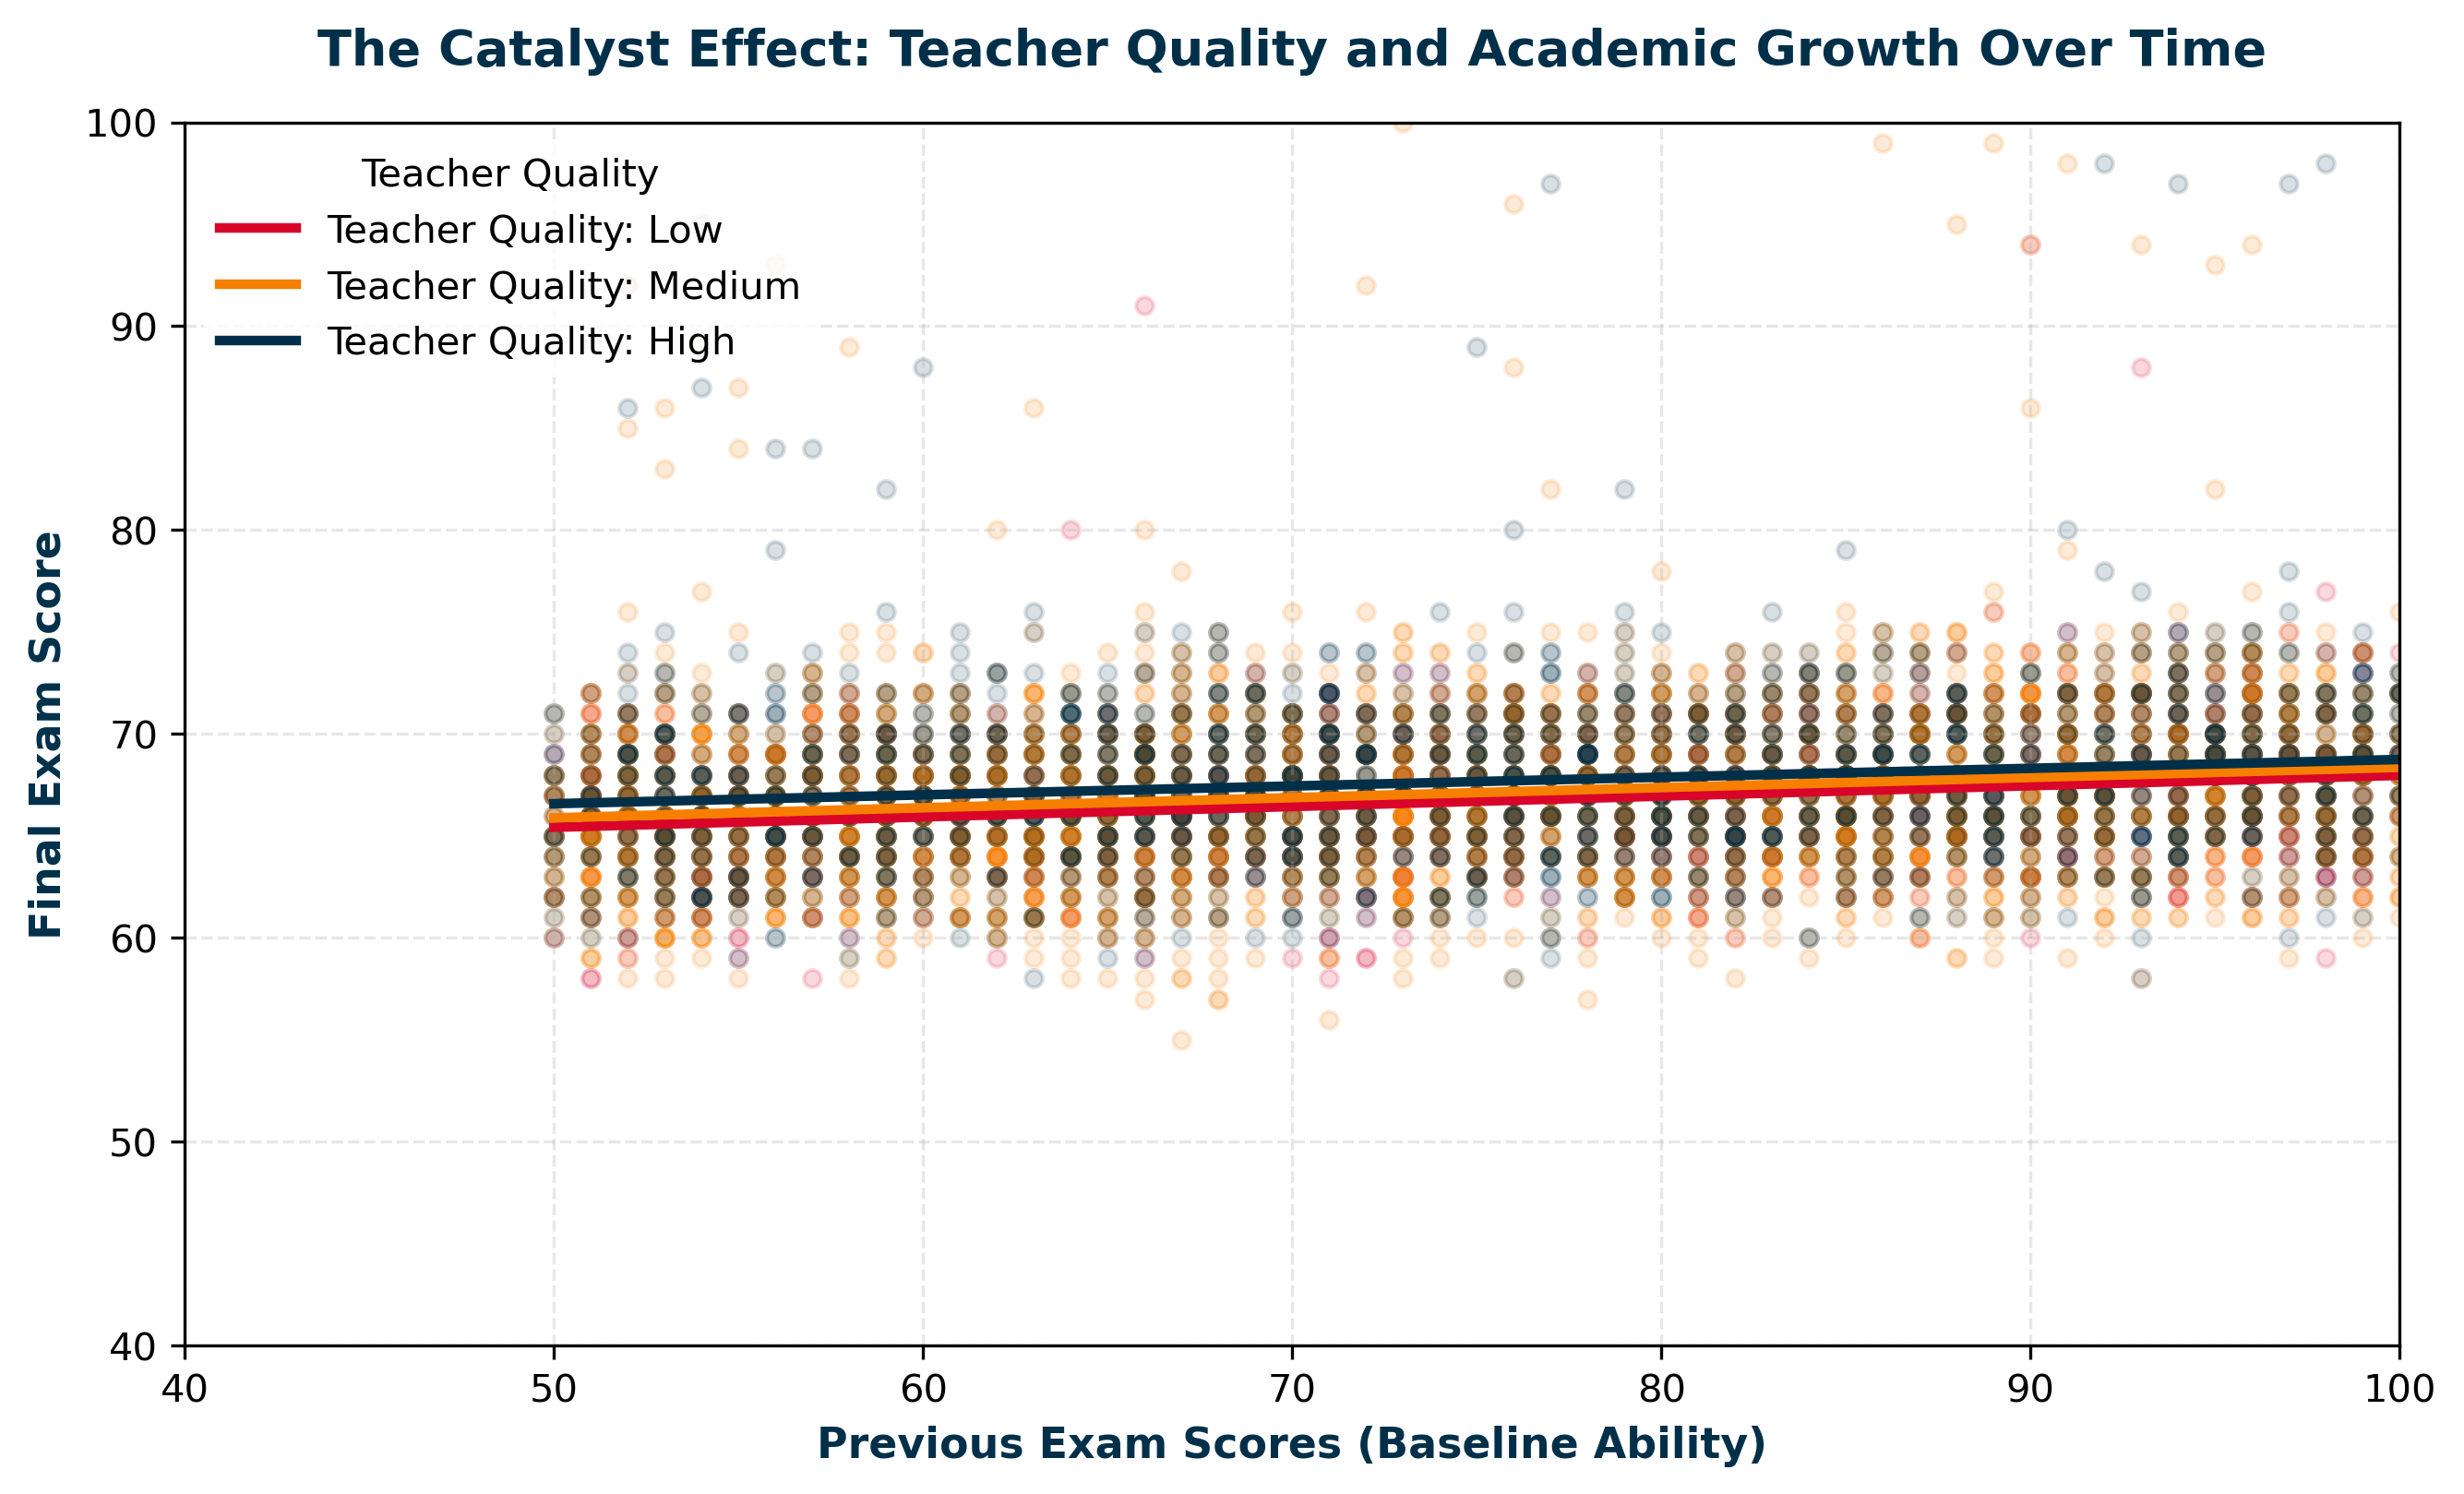

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('StudentPerformanceFactors.csv')

df_clean = df.dropna(subset=['Teacher_Quality']).copy()

teacher_order = ['Low', 'Medium', 'High']

df_clean['Prev_Score_Bin'] = pd.cut(df_clean['Previous_Scores'], bins=[40, 60, 75, 90, 100], labels=['40-60', '61-75', '76-90', '91-100'])

palette = {'Low': '#D90429', 'Medium': '#F77F00', 'High': '#003049'}

fig, ax = plt.subplots(figsize=(9, 5.5), dpi=300)

for t_qual in teacher_order:
    sub = df_clean[df_clean['Teacher_Quality'] == t_qual]
    sns.regplot(
        data=sub,
        x='Previous_Scores',
        y='Exam_Score',
        ax=ax,
        scatter_kws={'alpha': 0.15, 's': 20, 'color': palette[t_qual]},
        line_kws={'linewidth': 2.5, 'label': f'Teacher Quality: {t_qual}'},
        color=palette[t_qual],
        ci=None
    )

ax.set_title("The Catalyst Effect: Teacher Quality and Academic Growth Over Time", fontsize=13, fontweight='bold', pad=15, color='#003049')
ax.set_xlabel("Previous Exam Scores (Baseline Ability)", fontsize=11, fontweight='bold', color='#003049')
ax.set_ylabel("Final Exam Score", fontsize=11, fontweight='bold', color='#003049')
ax.set_xlim(40, 100)
ax.set_ylim(40, 100)

ax.legend(title="Teacher Quality", frameon=True, facecolor='white', edgecolor='none', loc='upper left')
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()